In [109]:
import numpy as np
import matplotlib.pyplot as plt
import thermodynamics as thermo
import ODESolve_slow as ODE

In [111]:
def sth(T):
    sth=((2*np.pi**2*2*T**3)/45)+thermo.s(10,0.511,2)+thermo.s(10,0.511,2)
    return sth
print (sth(10))

2412.1348418210628


In [113]:
def dsthdT(T):
    dsthdT=(6*np.pi**2*2*T**2)/45+thermo.dsdT(10,0.511,2)+thermo.dsdT(10,0.511,2)
    return dsthdT

In [117]:
def ptot(T,a):
    ptot=(np.pi**2*2*T**4)/30+thermo.p(10,0.511,2)+thermo.p(10,0.511,2)+thermo.p(1/a,0,6)
    return ptot

In [127]:
def f(a,y,p):
   
    T,t=y
    der = np.zeros(2)
   
    der[0] = -(3*a**2*sth(T))/(a**3*dsthdT(T))
    der[1] = (1/a)*((8*np.pi*ptot(T,a))/(3*(1.22*10**28)**2))**(1/2)

    
    return der

a0=0.1
y0=np.array([10,0])
dx0=0.001
p=None

N_step = 1000
dN = 2
x_final = 100

print(f(a0,y0,p)) 
a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

[-9.99879777e+01  4.46148637e-25]
True


(10, 0.01)

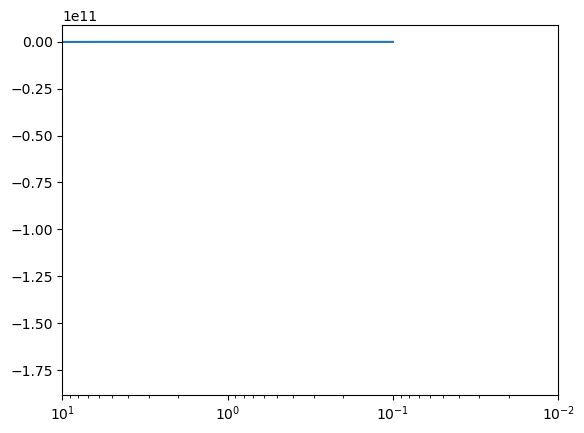

In [131]:
plt.figure()
T=y[:,0]
z=sth(T)*a**3
plt.semilogx(a,z)
plt.xlim(10,0.01)

   
